# imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyquaternion import Quaternion
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
"""
matplotlib.rcParams.update({'font.size': 20})
rc_fonts = {
    "font.family": "serif",
    "font.size": 20,
    'figure.figsize': (5, 3),
    "text.usetex": True
}
matplotlib.rcParams.update(rc_fonts)
"""
import sys 
sys.path.append("../General_Functions/")

from Flow_functions import *
from Geometric_functions import *
from Strategies import Triangulation3D

In [9]:
FlowGradient = GradientStresslet  # Note: it should work with a strain or another flow
grad_name = "GradientStresslet" # For saving porpouses
e3 = np.array([1, 0, 0])  # orientation of the flow
Nagent = 100  # number of agent positions (in the quarter circle of radius 1)
Norientation = 100
Duration = 255 # Max number of timesteps in simulations
dt = .01 # timestep lenght
AntennaeLength = .01 # Half inter-sensors distance
twist = 0.3 # Rotation around swimming direction t

# initialisation of arrays
agent_thetas = np.linspace(0, np.pi / 2, num=Nagent, endpoint=True)
agent_positions = np.array(
    [np.sin(agent_thetas), 0 * agent_thetas, np.cos(agent_thetas)]
).T

T_directions = np.zeros((Nagent, Norientation, 3))
tmean = np.zeros(Nagent)
gamma_perf = np.zeros(Nagent)

In [28]:
# Calculation of performance
gamma_perf = np.zeros(Nagent)
tmean = np.zeros((Nagent, 3))

for a in range(Nagent):
    agent_position = np.copy(agent_positions[a])
    for trials_i in range(Norientation):
        alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
        RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

        n_Triangulation = np.dot(RotationMatrix,[0, 1, 0])
        b_Triangulation = np.dot(RotationMatrix,[0, 0, 1])
        t_Triangulation = np.dot(RotationMatrix,[1, 0, 0])

        # Evaluate the inferred direction once
        x1 = agent_position + AntennaeLength*n_Triangulation
        x2 = agent_position - AntennaeLength*n_Triangulation
        Gradient_x1 = np.dot(FlowGradient(e3, x1), n_Triangulation)
        Gradient_x2 = np.dot(FlowGradient(e3, x2), n_Triangulation)
        
        TargetDirection = Triangulation3D(x1, Gradient_x1, x2, Gradient_x2)
        
        T_directions[a, trials_i,:] = (TargetDirection/np.linalg.norm(TargetDirection)).copy()
    tmean[a] = T_directions.mean(axis = (0, 1))
    gamma_perf[a] = np.dot(tmean[a], -agent_position)
    
print("y component of strategy", tmean[:,1])

y component of strategy [0.00373025 0.00426295 0.00329216 0.00236178 0.00318822 0.00351847
 0.00299604 0.00428842 0.00366923 0.00276106 0.00239039 0.00244579
 0.00264146 0.00223437 0.00212318 0.00214215 0.00255256 0.00095409
 0.00134855 0.00113587 0.00168253 0.00209771 0.00211317 0.00284729
 0.00277633 0.002745   0.00237142 0.00276978 0.00305745 0.00295589
 0.00269793 0.0027407  0.00239607 0.00213623 0.00250414 0.0018677
 0.00222118 0.00246276 0.00236491 0.00245934 0.00251576 0.00294978
 0.00303199 0.00307708 0.00241024 0.00277947 0.00163847 0.00227508
 0.00230597 0.00234327 0.00261651 0.0033165  0.00292479 0.00324999
 0.00414077 0.00454488 0.00456376 0.00449222 0.00493201 0.00484662
 0.00405179 0.00548208 0.00548293 0.00491682 0.00552929 0.00491365
 0.00422974 0.00433104 0.0044945  0.00340666 0.00271468 0.00387346
 0.00444848 0.0033884  0.00423369 0.00398749 0.00478636 0.00520743
 0.00523504 0.00515437 0.00616864 0.00667708 0.00661514 0.00789422
 0.00603908 0.00639478 0.00612731 0.006

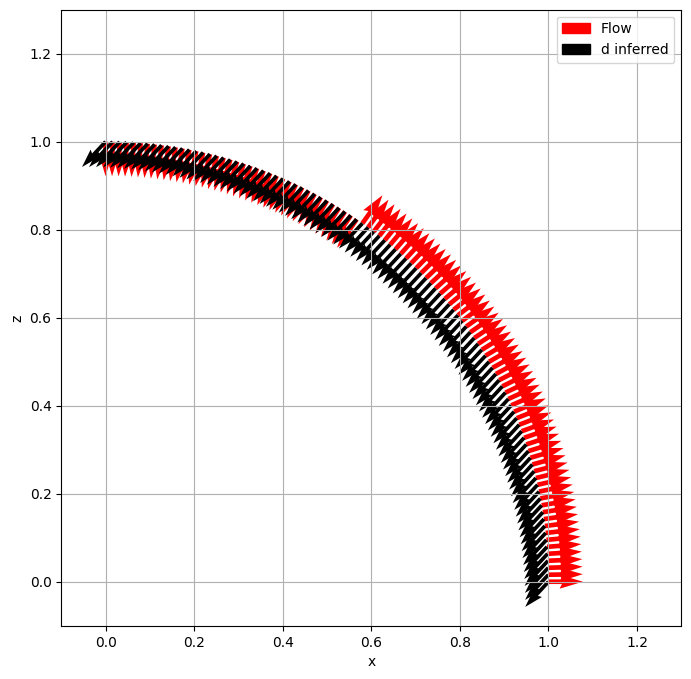

In [29]:

import matplotlib.patches as mpatches
plt.figure(figsize=(8,8))
for i in range(len(agent_positions)):
    plt.quiver(
        agent_positions[i,0],
        agent_positions[i,2],
        FlowStresslet(e, agent_positions[i])[0],
        FlowStresslet(e, agent_positions[i])[2],
        color='red'
    )
plt.quiver(
    agent_positions[:,0],
    agent_positions[:,2],
    tmean[:,0],
    tmean[:,2],
)


    
plt.xlim([-0.1, 1.3])
plt.ylim([-0.1, 1.3])
plt.xlabel('x')
plt.ylabel('z')
# --- Build custom legend handles ---
flow_patch = mpatches.FancyArrow(0, 0, 0.3, 0, color='red', width=0.05)
d_inferred_patch = mpatches.FancyArrow(0, 0, 0.3, 0, color='black', width=0.05)

# Add to legend
plt.legend(
    [flow_patch, d_inferred_patch],
    ['Flow', 'd inferred'],
    loc='upper right',
    frameon=True
)
plt.grid(True)
plt.show()